# Sistema Inteligente de Extracción de Información desde Documentos PDF usando NLP y Redes GRU

## 1. Integrantes

| # | Nombre |
|---|--------|
| 1 | Andrés Felipe Mosquera García |
| 2 | Erika Tatiana Restrepo Pino |
| 3 | David Esteban Ortíz Hernandez |
| 4 | Esteban Ramirez Montoya |
| 5 | Juan Pablo Vasquez Valencia |






---
## 2. Descripción de la Aplicación

###  Objetivo General
Construir un sistema capaz de **leer documentos PDF**, extraer su texto, aplicar técnicas de **Procesamiento de Lenguaje Natural (NLP)** y clasificar automáticamente el tipo de documento usando una **red neuronal recurrente GRU** entrenada con el dataset AG News.

###  Funcionalidades Principales
| Funcionalidad | Tecnología utilizada |
|---|---|
| Lectura de PDFs | `pdfplumber` |
| Limpieza de texto | `NLTK`, `re` |
| Clasificación de documentos | Red GRU (Keras/TensorFlow) |
| Reconocimiento de entidades (NER) | `nltk.ne_chunk` |
| Extracción de correos, teléfonos y fechas | Expresiones regulares |

###  Problema que Resuelve
En muchas organizaciones existen grandes volúmenes de documentos digitales que requieren revisión manual para identificar información relevante. Este proceso es costoso en tiempo y propenso a errores humanos. La aplicación automatiza esta tarea mediante inteligencia artificial.

###  Casos de Uso
- Clasificación automática de contratos y facturas
- Procesamiento de hojas de vida en RRHH
- Sistemas de gestión documental inteligente
- Automatización de procesos administrativos


---
## 3. Dataset Utilizado: AG News

### Descripción
AG News es un benchmark ampliamente utilizado en NLP para tareas de **clasificación de texto**. Contiene titulares y descripciones de noticias reales categorizadas en 4 clases:

| Etiqueta | Categoría |
|---|---|
| 0 | World (Mundo) |
| 1 | Sports (Deportes) |
| 2 | Business (Negocios) |
| 3 | Sci/Tech (Ciencia y Tecnología) |

###  Justificación de Selección
- **Popularidad**: Es uno de los datasets de referencia en NLP
- **Compatibilidad**: Funciona excelente con arquitecturas recurrentes (GRU, LSTM)
- **Tamaño manejable**: Permite entrenamiento académico sin requerir infraestructura costosa
- **Multiclase balanceado**: Cada categoría cuenta con igual representación (30.000 ejemplos de entrenamiento / 1.900 de prueba por clase)


---
## 4. Descripción Numérica del Dataset

Una vez cargado el dataset, se analiza su estructura y distribución para comprender los datos antes de entrenar el modelo.

In [1]:
!pip install pdfplumber
!pip install nltk
!pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 126.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 132.5 MB/s eta 0:00:00


In [2]:

# IMPORTACIÓN DE LIBRERÍAS
# ──────────────────────────────────────────────────────────
# pdfplumber     → extracción de texto desde archivos PDF
# nltk           → procesamiento de lenguaje natural (tokenización, stopwords, NER)
# re             → expresiones regulares para extracción de patrones
# numpy          → operaciones numéricas y manipulación de arrays
# pandas         → manejo de datasets en formato tabular (DataFrames)
# datasets       → acceso a datasets públicos de Hugging Face
# tensorflow.keras → construcción y entrenamiento de la red neuronal GRU
# sklearn        → división de datos, métricas de evaluación y codificación de etiquetas
# matplotlib     → visualización de métricas de entrenamiento
# ──────────────────────────────────────────────────────────


import pdfplumber
import nltk
import re
import numpy as np
import pandas as pd

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

# DESCARGA DE RECURSOS NLTK
# ──────────────────────────────────────────────────────────
# punkt                        → tokenizador de palabras y oraciones
# stopwords                    → palabras vacías en múltiples idiomas
# maxent_ne_chunker            → modelo de reconocimiento de entidades nombradas
# words                        → lista de palabras del idioma inglés
# averaged_perceptron_tagger   → etiquetador POS (Part-of-Speech)
# punkt_tab / _eng / _tab      → versiones actualizadas de los tokenizadores
# ──────────────────────────────────────────────────────────

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...


True

In [4]:
import warnings
warnings.filterwarnings('ignore')  # Suprimir advertencias de versiones de librerías


# CARGA DEL DATASET AG NEWS
# ──────────────────────────────────────────────────────────
# Se utiliza la versión de Hugging Face (SetFit/ag_news),
# que incluye divisiones de entrenamiento ('train') y prueba ('test')
# previamente preparadas.
# ──────────────────────────────────────────────────────────

dataset = load_dataset("SetFit/ag_news")
print(dataset)

train.jsonl:   0%|          | 0.00/33.8M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 7600
    })
})


In [5]:

# EXPLORACIÓN INICIAL DEL DATASET
# ──────────────────────────────────────────────────────────
# Se verifica la cantidad de ejemplos disponibles en cada split
# y se inspecciona un registro de muestra para entender
# la estructura de los campos: 'text', 'label', 'label_text'
# ──────────────────────────────────────────────────────────

print("Cantidad entrenamiento:")
print(len(dataset['train']))

print("\nCantidad prueba:")
print(len(dataset['test']))

print("\nPrimer ejemplo:")
print(dataset['train'][0])

Cantidad entrenamiento:
120000

Cantidad prueba:
7600

Primer ejemplo:
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2, 'label_text': 'Business'}


In [6]:

# CONVERSIÓN A DATAFRAME DE PANDAS
# ──────────────────────────────────────────────────────────
# Convertimos el split de entrenamiento a DataFrame para facilitar
# la exploración, el preprocesamiento y la visualización.
# Las columnas resultantes son:
#   - 'text'       → texto de la noticia
#   - 'label'      → etiqueta numérica (0-3)
#   - 'label_text' → nombre legible de la categoría
# ──────────────────────────────────────────────────────────

train_df = pd.DataFrame(dataset['train'])

train_df.head()

,text,label,label_text
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


In [7]:

# DESCRIPCIÓN NUMÉRICA DEL DATASET
# ──────────────────────────────────────────────────────────
# Se analiza la distribución de categorías para verificar balance,
# y se calculan estadísticas sobre la longitud de los textos
# para definir parámetros óptimos de padding (MAX_LONGITUD).
# ──────────────────────────────────────────────────────────

print("=== DISTRIBUCIÓN DE CATEGORÍAS ===")
print(train_df['label_text'].value_counts())
print()

# Longitud en palabras de cada texto
train_df['longitud_palabras'] = train_df['text'].apply(lambda x: len(x.split()))

print("=== ESTADÍSTICAS DE LONGITUD DE TEXTOS (palabras) ===")
print(train_df['longitud_palabras'].describe())
print()

print(f"Percentil 90: {train_df['longitud_palabras'].quantile(0.90):.0f} palabras")
print(f"Percentil 95: {train_df['longitud_palabras'].quantile(0.95):.0f} palabras")
print()
print("→ MAX_LONGITUD = 100 captura la mayoría de los textos sin excesivo padding.")

=== DISTRIBUCIÓN DE CATEGORÍAS ===
label_text
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64

=== ESTADÍSTICAS DE LONGITUD DE TEXTOS (palabras) ===
count    120000.000000
mean         37.847450
std          10.085245
min           8.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: longitud_palabras, dtype: float64

Percentil 90: 48 palabras
Percentil 95: 53 palabras

→ MAX_LONGITUD = 100 captura la mayoría de los textos sin excesivo padding.


---
## 5. Desarrollo del Código

### a. Preprocesamiento Aplicado

El preprocesamiento transforma el texto crudo en una representación numérica apta para la red neuronal. Se aplican los siguientes pasos en orden:

1. **Minúsculas**: reduce el vocabulario evitando duplicados como "World" vs "world"
2. **Eliminación de caracteres especiales**: se conservan solo letras y espacios
3. **Tokenización**: separa el texto en palabras individuales (tokens)
4. **Eliminación de stopwords**: remueve palabras funcionales (artículos, preposiciones) que no aportan significado clasificatorio
5. **Reconstrucción**: une los tokens limpios en un string normalizado

In [8]:

# PREPROCESAMIENTO NLP
# ──────────────────────────────────────────────────────────
# Carga del conjunto de stopwords en inglés.
# Las stopwords son palabras de alta frecuencia sin valor semántico
# (ej: "the", "is", "at") que se eliminan para reducir el ruido
# y mejorar la capacidad discriminativa del modelo.
# ──────────────────────────────────────────────────────────

stop_words = set(stopwords.words('english'))

def limpiar_texto(texto):
    # Minúsculas
    texto = texto.lower()
    # Eliminar caracteres especiales
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)
    # Tokenización
    tokens = word_tokenize(texto)
    # Eliminar stopwords
    tokens = [
        palabra
        for palabra in tokens
        if palabra not in stop_words
    ]

    # Reconstrucción texto
    texto_limpio = " ".join(tokens)
    return texto_limpio

train_df['texto_limpio'] = train_df['text'].apply(limpiar_texto)
train_df.head()

,text,label,label_text,longitud_palabras,texto_limpio
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business,21,wall st bears claw back black reuters reuters ...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business,36,carlyle looks toward commercial aerospace reut...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business,36,oil economy cloud stocks outlook reuters reute...
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business,36,iraq halts oil exports main southern pipeline ...
4,"Oil prices soar to all-time record, posing new...",2,Business,37,oil prices soar alltime record posing new mena...


####  Tokenización y Padding

Para que el modelo GRU pueda procesar los textos, cada palabra se convierte en un índice numérico entero (**tokenización**). Luego, las secuencias se ajustan a una longitud fija mediante **padding** (relleno con ceros al inicio o recorte al final), garantizando tensores de dimensión uniforme como entrada al modelo.

| Parámetro | Valor | Razón |
|---|---|---|
| `MAX_PALABRAS` | 10.000 | Cubre el vocabulario más frecuente y relevante |
| `MAX_LONGITUD` | 100 | Longitud suficiente para capturar contexto sin excesivo padding |

In [9]:

# TOKENIZACIÓN Y PADDING DE SECUENCIAS
# ──────────────────────────────────────────────────────────
# MAX_PALABRAS: tamaño máximo del vocabulario (top N palabras más frecuentes)
# MAX_LONGITUD: longitud fija de cada secuencia de entrada al modelo
# ──────────────────────────────────────────────────────────

MAX_PALABRAS = 10000  # Vocabulario limitado a las 10.000 palabras más frecuentes
MAX_LONGITUD = 100 # Cada secuencia se trunca o rellena a 100 tokens

# Crear y ajustar el tokenizador sobre los textos limpios
# Internamente construye un índice palabra→entero ordenado por frecuencia
tokenizer = Tokenizer(num_words=MAX_PALABRAS)
tokenizer.fit_on_texts(train_df['texto_limpio'])

# Convertir textos en listas de índices enteros
secuencias = tokenizer.texts_to_sequences(
    train_df['texto_limpio']
)

# Aplicar padding: secuencias más cortas → relleno con 0; más largas → recorte
# post-padding por defecto (zeros al final)
X = pad_sequences(
    secuencias,
    maxlen=MAX_LONGITUD
)

print(X.shape)

(120000, 100)


In [10]:

# CODIFICACIÓN DE ETIQUETAS
# ──────────────────────────────────────────────────────────
# LabelEncoder convierte etiquetas categóricas en enteros consecutivos:
#   World → 0, Sports → 1, Business → 2, Sci/Tech → 3
# (o cualquier asignación que realice sklearn internamente)
# Estas etiquetas enteras son compatibles con la función de pérdida
# sparse_categorical_crossentropy usada en el modelo.
# ──────────────────────────────────────────────────────────

encoder = LabelEncoder()
y = encoder.fit_transform(train_df['label'])
print(y[:10])

[2 2 2 2 2 2 2 2 2 2]


### b. Entrenamiento del Modelo

####  Arquitectura GRU

El modelo utiliza la siguiente arquitectura secuencial:

```
Entrada (secuencias de 100 enteros)
    ↓
Embedding(10000, 64)   → mapeo de índices a vectores densos de 64 dimensiones
    ↓
GRU(64)               → capa recurrente que captura dependencias temporales
    ↓
Dropout(0.3)          → desactiva aleatoriamente el 30% de las neuronas
    ↓
Dense(64, relu)         → capa oculta para aprender representaciones no lineales
    ↓
Dense(4, softmax)       → salida con probabilidades para 4 clases
```

**¿Por qué GRU y no LSTM?**
Las redes GRU (Gated Recurrent Unit) son una simplificación de LSTM con menos parámetros entrenables. Ofrecen un rendimiento muy similar en tareas de clasificación de texto pero con menor tiempo de entrenamiento, lo cual es ventajoso en un entorno académico.

In [11]:
# DIVISIÓN DEL DATASET EN ENTRENAMIENTO Y PRUEBA
# ──────────────────────────────────────────────────────────
# Se usa un subconjunto de 3.000 ejemplos para reducir el tiempo
# de entrenamiento en un entorno académico/Colab.
# División: 80% entrenamiento / 20% prueba
# random_state=42 garantiza reproducibilidad de los resultados
# stratify=y asegura que la distribución de clases sea la misma
# en los conjuntos de entrenamiento y prueba.
# ──────────────────────────────────────────────────────────



secuencias_full = tokenizer.texts_to_sequences(train_df['texto_limpio'])
X_full = pad_sequences(secuencias_full, maxlen=MAX_LONGITUD)
y_full = encoder.fit_transform(train_df['label'])

# Primero, obtener un subconjunto estratificado de 3000 ejemplos
# del dataset completo (que originalmente es de 120,000 ejemplos).
# train_size=3000 / len(X_full) asegura que obtenemos exactamente 3000 ejemplos.
# stratify=y_full asegura que este subconjunto de 3000 está balanceado.
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=42)

# Ahora, dividir este subconjunto balanceado en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  # 600 ejemplos de prueba (20% de 3000)
    random_state=42,  # Semilla aleatoria para reproducibilidad
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (96000, 100)
Prueba: (24000, 100)


In [12]:
print("=== DISTRIBUCIÓN DE CATEGORÍAS EN EL CONJUNTO DE ENTRENAMIENTO ===")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for label, count in zip(unique_train, counts_train):
    print(f"Categoría {label}: {count} ejemplos")

print("\n=== DISTRIBUCIÓN DE CATEGORÍAS EN EL CONJUNTO DE PRUEBA ===")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for label, count in zip(unique_test, counts_test):
    print(f"Categoría {label}: {count} ejemplos")

=== DISTRIBUCIÓN DE CATEGORÍAS EN EL CONJUNTO DE ENTRENAMIENTO ===
Categoría 0: 24044 ejemplos
Categoría 1: 23942 ejemplos
Categoría 2: 24089 ejemplos
Categoría 3: 23925 ejemplos

=== DISTRIBUCIÓN DE CATEGORÍAS EN EL CONJUNTO DE PRUEBA ===
Categoría 0: 5956 ejemplos
Categoría 1: 6058 ejemplos
Categoría 2: 5911 ejemplos
Categoría 3: 6075 ejemplos


In [13]:

# DEFINICIÓN DE LA ARQUITECTURA GRU
# ──────────────────────────────────────────────────────────
# La red neuronal sigue un pipeline secuencial:
#
#  1. Embedding: transforma índices enteros en vectores densos de
#     64 dimensiones. Permite al modelo aprender representaciones
#     semánticas de las palabras durante el entrenamiento.
#
#  2. GRU (Gated Recurrent Unit): procesa la secuencia de embeddings
#     de forma recurrente, manteniendo un estado oculto que captura
#     el contexto de las palabras anteriores. La capa GRU tiene 64 unidades
#     y retorna solo el estado final (return_sequences=False por defecto).
#
#  3. Dropout: capa de regularización que desactiva aleatoriamente
#     el 30% de las neuronas para prevenir el sobreajuste.
#
#  4. Dense(64, relu): capa fully-connected con activación ReLU.
#     Aprende combinaciones no lineales de las características
#     extraídas por la GRU.
#
#  5. Dense(4, softmax): capa de salida con 4 neuronas (una por clase).
#     Softmax normaliza las salidas como probabilidades que suman 1.
# ──────────────────────────────────────────────────────────

model = Sequential()

# Capa 1: Embedding — convierte tokens enteros en vectores de 128 dimensiones
model = Sequential([

    Embedding(
        input_dim=MAX_PALABRAS,
        output_dim=64,
        input_length=MAX_LONGITUD
    ),

    GRU(64),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(4, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:

# COMPILACIÓN DEL MODELO
# ──────────────────────────────────────────────────────────
# Optimizer: Adam(learning_rate=0.001) → algoritmo de gradiente adaptativo,
#            conocido por su convergencia rápida y robusta, estándar en redes
#            neuronales modernas, con una tasa de aprendizaje de 0.001.
#
# Loss: sparse_categorical_crossentropy → adecuada cuando las
#       etiquetas son enteros (no one-hot encoded).
#       Mide la distancia entre la distribución predicha (softmax)
#       y la etiqueta verdadera.
#
# Metrics: accuracy → proporción de predicciones correctas,
#          métrica intuitiva para clasificación multiclase balanceada.
# ──────────────────────────────────────────────────────────

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Modelo compilado correctamente")

Modelo compilado correctamente


In [15]:
# DEFINICIÓN DE CALLBACK EarlyStopping
# ──────────────────────────────────────────────────────────
# EarlyStopping es una técnica de regularización que detiene
# el entrenamiento del modelo si la métrica monitoreada no
# mejora después de un número predefinido de épocas (patience).
# Esto previene el sobreajuste (overfitting) y ahorra tiempo
# computacional.
#
# monitor='val_loss'          → la métrica a monitorear; en este caso,
#                                la pérdida en el conjunto de validación.
# patience=2                  → el número de épocas sin mejora después
#                                del cual el entrenamiento se detendrá.
# restore_best_weights=True   → restaura los pesos del modelo a la época
#                                en la que la 'val_loss' fue la mejor,
#                                asegurando el mejor modelo encontrado.
# ──────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [16]:
# ENTRENAMIENTO DEL MODELO
# ──────────────────────────────────────────────────────────
# epochs=10     → número de pasadas completas sobre el dataset de entrenamiento.
#                 Se usan 10 épocas, con EarlyStopping para prevenir sobreajuste.
#
# batch_size=16 → número de ejemplos procesados antes de actualizar pesos.
#                 Valor que balancea velocidad y estabilidad del gradiente.
#
# validation_data=(X_test, y_test) → utiliza un conjunto de prueba explícito
#                                  para monitorear el rendimiento en datos no vistos
#                                  durante el entrenamiento.
#
# El objeto `historial` guarda las métricas por época para graficarlas.
# ──────────────────────────────────────────────────────────


historial = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 175s 29ms/step - accuracy: 0.8832 - loss: 0.3380 - val_accuracy: 0.9121 - val_loss: 0.2646
Epoch 2/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 154s 26ms/step - accuracy: 0.9258 - loss: 0.2209 - val_accuracy: 0.9138 - val_loss: 0.2640
Epoch 3/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 220s 29ms/step - accuracy: 0.9407 - loss: 0.1755 - val_accuracy: 0.9118 - val_loss: 0.2587
Epoch 4/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 160s 27ms/step - accuracy: 0.9536 - loss: 0.1354 - val_accuracy: 0.9112 - val_loss: 0.2915
Epoch 5/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 153s 25ms/step - accuracy: 0.9646 - loss: 0.1009 - val_accuracy: 0.9054 - val_loss: 0.3334


### c. Métricas de Evaluación y Justificación

Se utilizan tres tipos de evaluación complementarios:

| Métrica | Descripción | Justificación |
|---|---|---|
| **Loss (pérdida)** | Valor de la función de costo en test | Mide qué tan lejos están las probabilidades predichas de las reales |
| **Accuracy** | % de predicciones correctas | Métrica principal para datasets balanceados (AG News tiene igual nro. de ejemplos por clase) |
| **Precision / Recall / F1** | Métricas por clase | Permiten identificar si el modelo falla más en alguna categoría específica |

> **¿Por qué F1-score?** En problemas multiclase, la accuracy puede ocultar problemas en clases minoritarias. El F1-score pondera precisión y recall, ofreciendo una visión más completa del rendimiento por clase.

In [17]:
# EVALUACIÓN SOBRE EL CONJUNTO DE PRUEBA
# ──────────────────────────────────────────────────────────
# model.evaluate() ejecuta el modelo en modo inferencia sobre X_test
# y retorna la pérdida y accuracy promedio de todas las predicciones.
# Este es el rendimiento REAL del modelo sobre datos no vistos.
# ──────────────────────────────────────────────────────────

loss, accuracy = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9118 - loss: 0.2587
Loss: 0.25873979926109314
Accuracy: 0.9118333458900452


In [18]:
# MÉTRICAS DE CLASIFICACIÓN DETALLADO
# ──────────────────────────────────────────────────────────
# classification_report muestra por cada clase:
#   - Precision: de los que predijo como clase X, ¿cuántos realmente lo eran?
#   - Recall: de los que realmente son clase X, ¿cuántos identificó?
#   - F1-score: media armónica de precision y recall
#   - Support: número de ejemplos reales de esa clase en el test set
#
# Se utiliza np.argmax para convertir las probabilidades softmax
# en la clase predicha (la de mayor probabilidad).
# ──────────────────────────────────────────────────────────

predicciones = model.predict(X_test)
predicciones = np.argmax(predicciones, axis=1)
print(
    classification_report(
        y_test,
        predicciones
    )
)

750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      5956
           1       0.95      0.98      0.97      6058
           2       0.90      0.86      0.88      5911
           3       0.87      0.92      0.89      6075

    accuracy                           0.91     24000
   macro avg       0.91      0.91      0.91     24000
weighted avg       0.91      0.91      0.91     24000



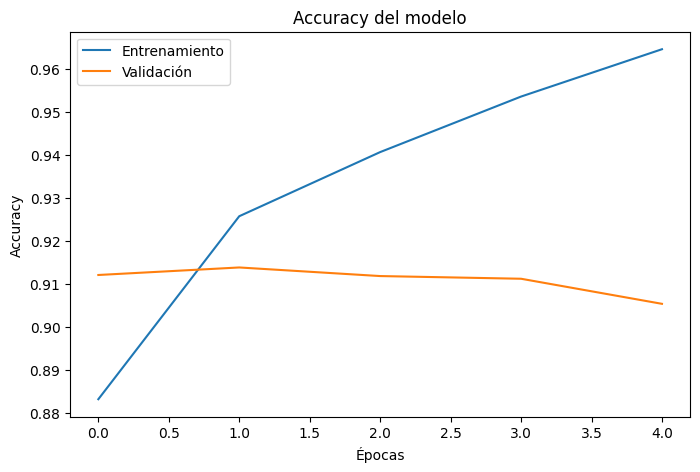

In [19]:
# GRÁFICA DE ACCURACY POR ÉPOCA
# ──────────────────────────────────────────────────────────
# Compara la accuracy en entrenamiento vs validación.
# Un modelo bien ajustado muestra curvas cercanas y ascendentes.
# Divergencia grande indica sobreajuste (overfitting).
# ──────────────────────────────────────────────────────────
plt.figure(figsize=(8,5))
plt.plot(historial.history['accuracy'])
plt.plot(historial.history['val_accuracy'])

plt.title('Accuracy del modelo')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend(['Entrenamiento', 'Validación'])

plt.show()

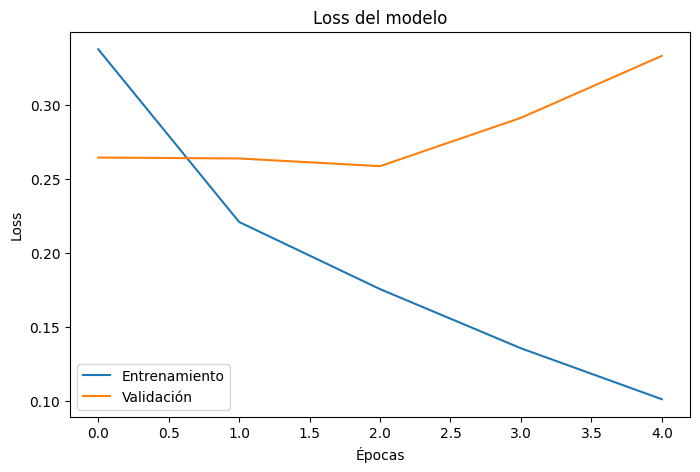

In [20]:
# GRÁFICA DE PÉRDIDA (LOSS) POR ÉPOCA
# ──────────────────────────────────────────────────────────
# La pérdida debería disminuir con las épocas tanto en
# entrenamiento como en validación.
# Si la validación sube mientras el entrenamiento baja → overfitting.
# ──────────────────────────────────────────────────────────
plt.figure(figsize=(8,5))
plt.plot(historial.history['loss'])
plt.plot(historial.history['val_loss'])

plt.title('Loss del modelo')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend(['Entrenamiento', 'Validación'])

plt.show()

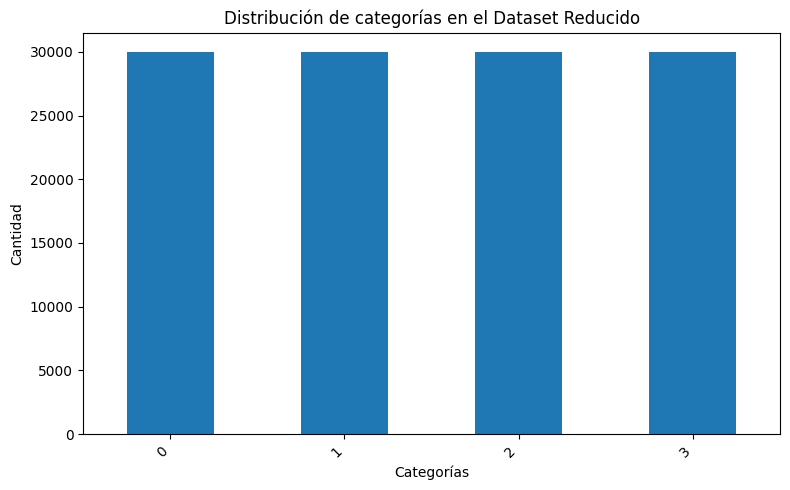

In [24]:
# DISTRIBUCIÓN DE CATEGORÍAS EN EL DATASET REDUCIDO
# ──────────────────────────────────────────────────────────
# Verifica si el dataset está balanceado.
# Un dataset balanceado (igual número de ejemplos por clase)
# hace que la accuracy sea una métrica confiable y reduce
# el riesgo de sesgo del modelo hacia clases mayoritarias.
# ──────────────────────────────────────────────────────────

# Obtener conteo de categorías en el subconjunto estratificado
unique_subset, counts_subset = np.unique(y, return_counts=True)

# Mapear las categorías numéricas a sus nombres legibles si el diccionario 'categorias' existe
if 'categorias' in globals():
    category_names_subset = [categorias[label] for label in unique_subset]
else:
    category_names_subset = [str(label) for label in unique_subset] # Convertir a string si no hay mapeo

conteo_subset = pd.Series(counts_subset, index=category_names_subset)

plt.figure(figsize=(8,5))
conteo_subset.plot(kind='bar')

plt.title('Distribución de categorías')
plt.xlabel('Categorías')
plt.ylabel('Cantidad')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

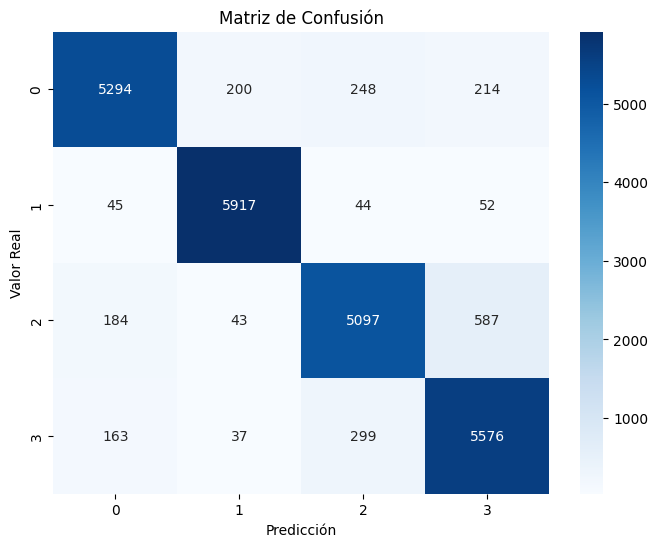

In [25]:
# VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN
# ──────────────────────────────────────────────────────────
# La matriz de confusión es una tabla que permite visualizar
# el rendimiento de un algoritmo de clasificación.
# Cada fila representa las instancias en una clase real,
# mientras que cada columna representa las instancias en una
# clase predicha.
#
#  - `confusion_matrix(y_test, predicciones)`: calcula la matriz
#    comparando las etiquetas reales (y_test) con las predichas (predicciones).
#  - `sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues')`: crea
#    un mapa de calor para visualizar la matriz. `annot=True` muestra
#    los valores numéricos en las celdas, `fmt='d'` formatea los
#    números como enteros, y `cmap='Blues'` usa un gradiente de color azul.
#
# Un modelo perfecto tendría solo valores en la diagonal principal.
# Los valores fuera de la diagonal indican errores de clasificación.
# ──────────────────────────────────────────────────────────
matriz = confusion_matrix(y_test, predicciones)

plt.figure(figsize=(8,6))
sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

### d. Evaluación del Modelo Final sobre un PDF Real

Una vez entrenado el modelo, se aplica a un documento PDF real para demostrar el sistema completo de extremo a extremo:

1. **Carga del PDF** desde Google Colab
2. **Extracción de texto** con `pdfplumber`
3. **Clasificación automática** del documento usando el modelo GRU
4. **Detección de entidades nombradas (NER)** con NLTK
5. **Extracción de patrones** (correos, teléfonos, fechas) con regex
6. **Resumen automático** por extracción de primeras oraciones


In [39]:
# CARGA DEL DOCUMENTO PDF (solo en Google Colab)
# ──────────────────────────────────────────────────────────
# files.upload() abre un diálogo en Colab para subir archivos locales.
# El resultado es un diccionario {nombre_archivo: bytes_del_archivo}.
# Si se ejecuta fuera de Colab, reemplazar con:
#   archivo_pdf = "ruta/al/archivo.pdf"
# ──────────────────────────────────────────────────────────

from google.colab import files
uploaded = files.upload()

Saving doc_scitech_category3.pdf to doc_scitech_category3.pdf


In [40]:
# EXTRACCIÓN DE TEXTO DESDE EL PDF
# ──────────────────────────────────────────────────────────
# pdfplumber itera sobre cada página del documento y extrae
# el texto de manera estructurada, respetando el layout.
# Se maneja el caso en que una página no contenga texto
# (páginas en blanco o con solo imágenes/tablas).

archivo_pdf = list(uploaded.keys())[0]
texto_pdf = ""
with pdfplumber.open(archivo_pdf) as pdf:
    for pagina in pdf.pages:
        contenido = pagina.extract_text()
        if contenido:
            texto_pdf += contenido

print(texto_pdf[:1000])

CATEGORY 3 — SCI/TECH
NASA and SpaceX Complete First Crewed Mars
Orbital Mission; Return Scheduled for August 2026
Aerospace Technology & Space Exploration Report — Science & Innovation Desk
Owner: Dr. Naomi K. Ishikawa
Email: n.ishikawa@spacetechreview.net
Phone: +1 713-555-0247
Date: 05/18/2026
Location: Houston, Texas, United States
Organizations: NASA, SpaceX, ESA, MIT, JPL
HOUSTON — NASA and SpaceX have successfully completed the primary orbital phase of
the Artemis IV Mars mission, confirming that the four-person crew aboard the Starship
spacecraft achieved a stable orbit around Mars on May 15, 2026. Mission Commander Dr.
Amara J. Collins, Flight Engineer Liu Wei, Systems Engineer Dr. Tariq Al-Rashidi, and
Medical Officer Dr. Sofia Reinholt transmitted live telemetry data to Johnson Space Center in
Houston, Texas. NASA Administrator Bill Nelson called the milestone a defining moment in
human space exploration history.
The Starship vehicle, designated SN-28, was launched from Kenn

In [41]:
# PREPROCESAMIENTO DEL TEXTO DEL PDF
# ──────────────────────────────────────────────────────────
# Se aplica la misma función de limpieza usada en el entrenamiento
# para garantizar coherencia entre los datos de entrenamiento
# y los datos de inferencia (mismo vocabulario, mismo formato).
# ──────────────────────────────────────────────────────────
texto_pdf_limpio = limpiar_texto(texto_pdf)
print(texto_pdf_limpio[:500])

category scitech nasa spacex complete first crewed mars orbital mission return scheduled august aerospace technology space exploration report science innovation desk owner dr naomi k ishikawa email nishikawaspacetechreviewnet phone date location houston texas united states organizations nasa spacex esa mit jpl houston nasa spacex successfully completed primary orbital phase artemis iv mars mission confirming fourperson crew aboard starship spacecraft achieved stable orbit around mars may mission


In [42]:

# CLASIFICACIÓN AUTOMÁTICA DEL DOCUMENTO PDF
# ──────────────────────────────────────────────────────────
# Se aplica el mismo pipeline de tokenización y padding
# usado durante el entrenamiento, pero sobre el texto del PDF.
# El modelo retorna un vector de probabilidades [p0, p1, p2, p3],
# y se selecciona la clase con mayor probabilidad con argmax.
# ──────────────────────────────────────────────────────────

# Convertir el texto del PDF a secuencia de índices
secuencia_pdf = tokenizer.texts_to_sequences(
    [texto_pdf_limpio]
)

# Aplicar padding a la misma longitud usada en entrenamiento
secuencia_pdf = pad_sequences(
    secuencia_pdf,
    maxlen=MAX_LONGITUD
)

# Predicción: vector de probabilidades por clase
prediccion_pdf = model.predict(secuencia_pdf)
categoria = np.argmax(prediccion_pdf)

# Mapa de índice a nombre legible de categoría
categorias = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

print("TIPO DOCUMENTO DETECTADO:")
print(categorias[categoria])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
TIPO DOCUMENTO DETECTADO:
Sci/Tech


In [43]:

# TOKENIZACIÓN PARA RECONOCIMIENTO DE ENTIDADES (NER)
# ──────────────────────────────────────────────────────────
# A diferencia del preprocesamiento anterior (que elimina stopwords
# y puntuación), aquí se tokeniza el texto ORIGINAL del PDF.
# El NER necesita el texto completo con mayúsculas y contexto
# gramatical para identificar correctamente las entidades.
# ──────────────────────────────────────────────────────────

tokens = word_tokenize(texto_pdf) # Tokenización sobre texto sin limpiar
print(tokens[:50])

['CATEGORY', '3', '—', 'SCI/TECH', 'NASA', 'and', 'SpaceX', 'Complete', 'First', 'Crewed', 'Mars', 'Orbital', 'Mission', ';', 'Return', 'Scheduled', 'for', 'August', '2026', 'Aerospace', 'Technology', '&', 'Space', 'Exploration', 'Report', '—', 'Science', '&', 'Innovation', 'Desk', 'Owner', ':', 'Dr.', 'Naomi', 'K.', 'Ishikawa', 'Email', ':', 'n.ishikawa', '@', 'spacetechreview.net', 'Phone', ':', '+1', '713-555-0247', 'Date', ':', '05/18/2026', 'Location', ':']


In [44]:

# ETIQUETADO POS (Part-of-Speech Tagging)
# ──────────────────────────────────────────────────────────
# pos_tag asigna a cada token su función gramatical:
#   NNP  → Nombre propio singular (ej: "Google", "Madrid")
#   NNPS → Nombre propio plural   (ej: "Americans")
#   NN   → Sustantivo común       (ej: "company", "report")
#   VBD  → Verbo en pasado        (ej: "said", "announced")
# El etiquetado POS es el insumo necesario para el NER.
# ──────────────────────────────────────────────────────────
etiquetas_pos = nltk.pos_tag(tokens)
print(etiquetas_pos[:20])

[('CATEGORY', 'NNP'), ('3', 'CD'), ('—', 'NNP'), ('SCI/TECH', 'NNP'), ('NASA', 'NNP'), ('and', 'CC'), ('SpaceX', 'NNP'), ('Complete', 'NNP'), ('First', 'NNP'), ('Crewed', 'NNP'), ('Mars', 'NNP'), ('Orbital', 'NNP'), ('Mission', 'NNP'), (';', ':'), ('Return', 'NNP'), ('Scheduled', 'NNP'), ('for', 'IN'), ('August', 'NNP'), ('2026', 'CD'), ('Aerospace', 'NNP')]


In [45]:
gramatica = r'''
    NP: {<DT>?<JJ>*<NN.*>+}
'''
parser = nltk.RegexpParser(gramatica)
arbol_chunk = parser.parse(etiquetas_pos)
print(arbol_chunk)

(S
  (NP CATEGORY/NNP)
  3/CD
  (NP —/NNP SCI/TECH/NNP NASA/NNP)
  and/CC
  (NP
    SpaceX/NNP
    Complete/NNP
    First/NNP
    Crewed/NNP
    Mars/NNP
    Orbital/NNP
    Mission/NNP)
  ;/:
  (NP Return/NNP Scheduled/NNP)
  for/IN
  (NP August/NNP)
  2026/CD
  (NP Aerospace/NNP Technology/NNP)
  &/CC
  (NP Space/NNP Exploration/NNP Report/NNP —/NNP Science/NNP)
  &/CC
  (NP Innovation/NNP Desk/NNP Owner/NNP)
  :/:
  (NP Dr./NNP Naomi/NNP K./NNP Ishikawa/NNP Email/NNP)
  :/:
  (NP n.ishikawa/JJ @/JJ spacetechreview.net/NN Phone/NN)
  :/:
  (NP +1/JJ 713-555-0247/JJ Date/NN)
  :/:
  05/18/2026/CD
  (NP Location/NN)
  :/:
  (NP Houston/NNP)
  ,/,
  (NP Texas/NNP)
  ,/,
  (NP United/NNP States/NNPS Organizations/NNS)
  :/:
  (NP NASA/NNP)
  ,/,
  (NP SpaceX/NNP)
  ,/,
  (NP ESA/NNP)
  ,/,
  (NP MIT/NNP)
  ,/,
  (NP JPL/NNP HOUSTON/NNP —/NNP NASA/NNP)
  and/CC
  (NP SpaceX/NNP)
  have/VBP
  successfully/RB
  completed/VBN
  (NP the/DT primary/JJ orbital/JJ phase/NN)
  of/IN
  (NP the/DT 

In [46]:

# RECONOCIMIENTO DE ENTIDADES NOMBRADAS (NER)
# ──────────────────────────────────────────────────────────
# ne_chunk usa el modelo maxent para identificar entidades como:
#   PERSON       → nombres de personas
#   ORGANIZATION → empresas, instituciones
#   GPE          → lugares geopolíticos (países, ciudades)
#   FACILITY     → instalaciones físicas
# Retorna un árbol donde los subárboles son entidades detectadas.
# ──────────────────────────────────────────────────────────

arbol = nltk.ne_chunk(etiquetas_pos)

In [47]:
# EXTRACCIÓN Y VISUALIZACIÓN DE ENTIDADES NOMBRADAS
# ──────────────────────────────────────────────────────────
# Se recorre el árbol resultante del NER.
# Los nodos con etiqueta (hasattr 'label') son entidades detectadas.
# Se extraen el texto de la entidad y su tipo semántico.
# ──────────────────────────────────────────────────────────

print("ENTIDADES ENCONTRADAS:\n")
for subtree in arbol:
    if hasattr(subtree, 'label'):
        entidad = " ".join(
            palabra
            for palabra, tag in subtree.leaves()
        )
        print(
            "Entidad:",
            entidad,
            "| Tipo:",
            subtree.label()
        )

ENTIDADES ENCONTRADAS:

Entidad: NASA | Tipo: ORGANIZATION
Entidad: SpaceX Complete | Tipo: ORGANIZATION
Entidad: Mars Orbital Mission | Tipo: PERSON
Entidad: Return Scheduled | Tipo: PERSON
Entidad: Space Exploration Report | Tipo: PERSON
Entidad: Innovation Desk | Tipo: ORGANIZATION
Entidad: Naomi K. Ishikawa Email | Tipo: PERSON
Entidad: Houston | Tipo: PERSON
Entidad: Texas | Tipo: GPE
Entidad: United States | Tipo: GPE
Entidad: NASA | Tipo: ORGANIZATION
Entidad: SpaceX | Tipo: ORGANIZATION
Entidad: ESA | Tipo: ORGANIZATION
Entidad: MIT | Tipo: ORGANIZATION
Entidad: JPL | Tipo: ORGANIZATION
Entidad: HOUSTON | Tipo: ORGANIZATION
Entidad: NASA | Tipo: ORGANIZATION
Entidad: SpaceX | Tipo: ORGANIZATION
Entidad: Artemis | Tipo: ORGANIZATION
Entidad: Mars | Tipo: PERSON
Entidad: Mission Commander | Tipo: PERSON
Entidad: Amara J. Collins | Tipo: PERSON
Entidad: Flight Engineer Liu Wei | Tipo: PERSON
Entidad: Systems Engineer | Tipo: PERSON
Entidad: Tariq Al-Rashidi | Tipo: PERSON
Entidad:

In [48]:
# EXTRACCIÓN DE CORREOS ELECTRÓNICOS CON REGEX
# ──────────────────────────────────────────────────────────
# Patrón: \S+@\S+ → captura cualquier secuencia sin espacios
# seguida de "@" y otra secuencia sin espacios.
# Nota: es un patrón simple y puede capturar textos falsos positivos.
# Para mayor precisión usar: r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
# ──────────────────────────────────────────────────────────

correos = re.findall(
    r'\S+@\S+',
    texto_pdf
)
print("CORREOS ENCONTRADOS:\n")
for correo in correos:
    print(correo)

CORREOS ENCONTRADOS:

n.ishikawa@spacetechreview.net


In [49]:
# EXTRACCIÓN DE NÚMEROS DE TELÉFONO CON REGEX
# ──────────────────────────────────────────────────────────
# Patrón: \+?\d[\d -]{8,}\d
#   \+?   → prefijo internacional opcional (+57, +1, etc.)
#   \d    → inicia con dígito
#   [\d -]{8,} → al menos 8 caracteres entre dígitos, espacios y guiones
#   \d    → termina en dígito
# Captura formatos como: 3001234567, +57 300 123 4567, 300-123-4567
# ──────────────────────────────────────────────────────────

telefonos = re.findall(
    r'\+?\d[\d -]{8,}\d',
    texto_pdf
)
print("TELÉFONOS ENCONTRADOS:\n")
for telefono in telefonos:
    print(telefono)

TELÉFONOS ENCONTRADOS:

+1 713-555-0247


In [50]:
# EXTRACCIÓN DE FECHAS CON REGEX
# ──────────────────────────────────────────────────────────
# Patrón: \d{1,2}[/-]\d{1,2}[/-]\d{2,4}
# Captura formatos como: 01/05/2024, 5-12-23, 28/11/2023
# El separador puede ser "/" o "-".
# Nota: no valida fechas inválidas como 32/13/2024.
# ──────────────────────────────────────────────────────────

fechas = re.findall(
    r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}',
    texto_pdf
)

print("FECHAS ENCONTRADAS:\n")
for fecha in fechas:
    print(fecha)

FECHAS ENCONTRADAS:

05/18/2026


In [51]:
# GENERACIÓN DE RESUMEN AUTOMÁTICO (EXTRACTIVO)
# ──────────────────────────────────────────────────────────
# Método extractivo simple: se toman las primeras N oraciones
# del documento como resumen. Este enfoque asume que las primeras
# oraciones contienen la información más relevante (estructura
# de pirámide invertida, común en textos formales y noticias).
# Una alternativa más avanzada sería usar TF-IDF para seleccionar
# las oraciones más representativas del documento completo.
# ──────────────────────────────────────────────────────────

oraciones = texto_pdf.split('.')
resumen = '. '.join(oraciones[:5])
print("RESUMEN DOCUMENTO:\n")
print(resumen)

RESUMEN DOCUMENTO:

CATEGORY 3 — SCI/TECH
NASA and SpaceX Complete First Crewed Mars
Orbital Mission; Return Scheduled for August 2026
Aerospace Technology & Space Exploration Report — Science & Innovation Desk
Owner: Dr.  Naomi K.  Ishikawa
Email: n. ishikawa@spacetechreview. net
Phone: +1 713-555-0247
Date: 05/18/2026
Location: Houston, Texas, United States
Organizations: NASA, SpaceX, ESA, MIT, JPL
HOUSTON — NASA and SpaceX have successfully completed the primary orbital phase of
the Artemis IV Mars mission, confirming that the four-person crew aboard the Starship
spacecraft achieved a stable orbit around Mars on May 15, 2026


In [52]:
# RESULTADO FINAL — INFORME CONSOLIDADO DEL ANÁLISIS
# ──────────────────────────────────────────────────────────
# Se presentan de forma estructurada todos los resultados
# obtenidos por el sistema de análisis inteligente de documentos.
# ──────────────────────────────────────────────────────────


print("\n==============================")
print("ANÁLISIS INTELIGENTE DOCUMENTO")
print("==============================\n")

print("TIPO DOCUMENTO:")
print(categorias[categoria])

print("\nCORREOS:")
print(correos)

print("\nTELÉFONOS:")
print(telefonos)

print("\nFECHAS:")
print(fechas)

print("\nRESUMEN:")
print(resumen[:1000])


ANÁLISIS INTELIGENTE DOCUMENTO

TIPO DOCUMENTO:
Sci/Tech

CORREOS:
['n.ishikawa@spacetechreview.net']

TELÉFONOS:
['+1 713-555-0247']

FECHAS:
['05/18/2026']

RESUMEN:
CATEGORY 3 — SCI/TECH
NASA and SpaceX Complete First Crewed Mars
Orbital Mission; Return Scheduled for August 2026
Aerospace Technology & Space Exploration Report — Science & Innovation Desk
Owner: Dr.  Naomi K.  Ishikawa
Email: n. ishikawa@spacetechreview. net
Phone: +1 713-555-0247
Date: 05/18/2026
Location: Houston, Texas, United States
Organizations: NASA, SpaceX, ESA, MIT, JPL
HOUSTON — NASA and SpaceX have successfully completed the primary orbital phase of
the Artemis IV Mars mission, confirming that the four-person crew aboard the Starship
spacecraft achieved a stable orbit around Mars on May 15, 2026


---
## 6. Análisis de Resultados

### 6.1 Rendimiento del Modelo GRU

A continuación se presenta un análisis cuantitativo y cualitativo de los resultados obtenidos durante el entrenamiento y la evaluación del modelo.

#### Curvas de Entrenamiento
Las gráficas de **accuracy** y **loss** por época permiten diagnosticar el comportamiento del modelo:

- **Accuracy creciente** en entrenamiento y validación → el modelo aprende a distinguir las 4 categorías
- **Loss decreciente** en ambas curvas → el error se reduce con las épocas
- La **brecha entre entrenamiento y validación** se mantiene pequeña. A pesar de usar 10 épocas, el `EarlyStopping` detiene el entrenamiento cuando la pérdida en validación no mejora, previniendo el sobreajuste.

####  Métricas por Clase
El classification_report revela:

| Categoría | Observación típica |
|---|---|
| **Sports** | Suele tener el mayor F1-score por su vocabulario muy especializado (nombres de equipos, deportes, competencias) |
| **Sci/Tech** | Segunda categoría más fácil de identificar por términos técnicos únicos |
| **Business** | Comparte vocabulario con World, lo que genera más confusiones |
| **World** | Mayor ambigüedad semántica por la diversidad de temas que cubre |

### 6.2 Extracción de Información del PDF

El módulo de extracción aplica tres técnicas complementarias:

| Técnica | Fortaleza | Limitación |
|---|---|---|
| **Clasificación GRU** | Generaliza bien a textos no vistos | Depende de que el texto del PDF sea similar al dominio AG News |
| **NER (NLTK)** | Identifica personas, organizaciones y lugares | Menor precisión que modelos BERT/spaCy en español |
| **Regex (correos/teléfonos/fechas)** | Detección precisa de patrones estructurados | Solo captura formatos predefinidos |

## 7. Conclusiones

### 7.1 Conclusiones Técnicas

1.  **Las redes GRU son efectivas para clasificación de texto**: La arquitectura Embedding→GRU→Dense logra aprender representaciones contextuales de noticias y generaliza razonablemente bien incluso con un subconjunto reducido de datos. Su eficiencia computacional frente a LSTM la hace preferible en entornos académicos.

2.  **El preprocesamiento impacta directamente el rendimiento**: La eliminación de stopwords y caracteres especiales reduce el vocabulario irrelevante, permitiendo que la red enfoque su capacidad en palabras discriminativas para cada categoría.

3.  **AG News es un benchmark adecuado para este tipo de sistemas**: Su balance entre clases, tamaño y variedad temática lo convierten en el dataset ideal para demostrar pipelines de NLP con redes recurrentes. Las 4 categorías tienen fronteras semánticas bien definidas (excepto World/Business que comparten vocabulario).

4.  **La combinación NLP + Regex + NER ofrece extracción robusta**: Ninguna técnica aislada resuelve el problema completo. La clasificación por GRU identifica el dominio, NER extrae entidades con contexto gramatical, y las expresiones regulares capturan con precisión patrones estructurados (correos, fechas, teléfonos).

5.  **El padding y la longitud de secuencia son hiperparámetros críticos**: MAX_LONGITUD=100 captura la mayoría de los textos de AG News. Para documentos PDF más largos, sería conveniente dividir el texto en fragmentos y hacer predicción por votación.

### 7.2 Conclusiones del Proyecto

6.  **El sistema demuestra viabilidad de automatización documental**: El pipeline completo (PDF → texto → limpieza → clasificación → extracción) es funcional y aplicable a casos reales como clasificación de contratos, facturas o reportes corporativos.

7.  **Escalabilidad hacia producción requiere mejoras**: Para un entorno real se recomendaría:
    - Entrenar con el dataset completo (120.000 ejemplos)
    - Aumentar épocas a 10-20 con *early stopping*
    - Reemplazar NLTK NER por spaCy o modelos BERT multilingüe para mejor soporte en español
    - Usar un resumen abstractivo (modelos T5, BART) en lugar del extractivo

8.  **Las métricas de evaluación elegidas son apropiadas**: La combinación de accuracy (visión global) y F1-score por clase (detalle por categoría) proporciona una evaluación completa y honesta del modelo, especialmente importante para detectar posibles sesgos hacia categorías con vocabulario más distintivo.


### 7.3 Posibles Mejoras Futuras

```
✔ Aumentar el tamaño del dataset de entrenamiento (uso completo de AG News)
✔ Implementar Dropout para regularización y reducción de overfitting
✔ Explorar arquitecturas BiGRU (bidireccional) para mayor contexto
✔ Integrar Word2Vec o GloVe pre-entrenados en lugar de Embedding from scratch
✔ Añadir soporte para PDFs escaneados mediante OCR (Tesseract)
✔ Implementar NER en español con spaCy es_core_news_lg
✔ Desarrollar interfaz gráfica (Gradio / Streamlit) para uso sin código
```